# Data Capture

In [157]:
import os
import time
import pandas as pd
from dataretrieval import waterdata
import dataretrieval
import numpy as np

In [158]:
parameter_key = [("Instantaneous computed discharge", "00060"),
                 ("Instantaneous water temperature", "00010"),
                 ("Instantaneous pH", "00400"),
                 ("Instantaneous diss. oxygen", "00300"),
                 ("Instantaneous specific conductance at 25 degrees Celsius", "00095"),
                 ("Instantaneous turbidity", "63680"),
                 ]
                #  ("Computed instantaneous total organic carbon", "00680"),
                #  ("Computed instantaneous diss. nitrate + nitrite", "00631"),
                #  ("Computed instantaneous total phosphorus", "00665")]

In [159]:
with open(r"c:\Users\epzausch\Desktop\usgs_waterdata_api_key.txt", "r") as f:
    api_key = f.read().strip()

In [163]:
dataretrieval.configure(dataretrieval.Configuration(api_key=api_key))
import os

os.environ["API_USGS_PAT"] = api_key

In [164]:


def fetch_usgs_data(
    pcode: tuple,
    period: str = "2024",
    refresh: bool = False
) -> pd.DataFrame:

    site_no = "08068500"
    parameter_code = pcode[1]

    fname = f"USGS_{parameter_code}_{period}.csv"
    filepath = os.path.join("USGS", fname)

    # Load cached data
    if not refresh and os.path.exists(filepath):

        print(f"Loading cached data from {fname}...")

        df = pd.read_csv(filepath)

        # Convert to timezone-naive datetime
        df["DateTime"] = (
            pd.to_datetime(df["DateTime"], utc=True)
            .dt.tz_localize(None)
        )

        df.set_index("DateTime", inplace=True)

        return df

    # Fetch data from USGS
    print(
        f"Fetching {parameter_code} data for {period} from USGS..."
    )

    start_date = f"{period}-01-01"
    end_date = f"{int(period) + 1}-01-01"

    df, metadata = waterdata.get_continuous(
        monitoring_location_id=f"USGS-{site_no}",
        parameter_code=parameter_code,
        time=f"{start_date}/{end_date}",
    )

    # Standardize output

    # Convert USGS timezone-aware timestamps to timezone-naive
    df["DateTime"] = (
        pd.to_datetime(df["time"], utc=True)
        .dt.tz_localize(None)
    )

    df.set_index("DateTime", inplace=True)

    # Keep only the measured value
    df = df[["value"]].copy()

    # Rename to your parameter name
    df.rename(columns={"value": pcode[0]}, inplace=True)

    # Remove duplicate timestamps
    df = df[~df.index.duplicated(keep="first")]

    # Sort chronologically
    df.sort_index(inplace=True)

    # Save cache
    os.makedirs("USGS", exist_ok=True)

    df.to_csv(filepath)

    return df


def fetch_many_years(
    pcode: tuple,
    start_year: int,
    end_year: int,
    refresh: bool = False
) -> pd.DataFrame:
    """
    Fetch USGS continuous data for multiple years and concatenate
    into a single DataFrame.
    """

    dfs = []

    for year in range(start_year, end_year + 1):

        df_year = fetch_usgs_data(
            pcode=pcode,
            period=str(year),
            refresh=refresh
        )

        dfs.append(df_year)

        # Pause between requests to avoid hitting the USGS service
        time.sleep(1)

    combined_df = pd.concat(dfs)

    # Remove any duplicate timestamps created at year boundaries
    combined_df = combined_df[
        ~combined_df.index.duplicated(keep="first")
    ]

    combined_df.sort_index(inplace=True)

    return combined_df


def fetch_all_parameters(
    start_year: int,
    end_year: int,
    refresh: bool = False
) -> pd.DataFrame:
    """
    Fetch USGS continuous data for all parameters in parameter_key
    and combine them into a single DataFrame.
    """

    dfs = []

    for pcode in parameter_key:

        print(f"\nFetching data for parameter {pcode[0]}...")

        df_param = fetch_many_years(
            pcode=pcode,
            start_year=start_year,
            end_year=end_year,
            refresh=refresh
        )

        dfs.append(df_param)

    combined_df = pd.concat(
        dfs,
        axis=1,
        join="outer",
        sort=True
    )

    combined_df.sort_index(inplace=True)

    return combined_df

In [171]:
df = fetch_all_parameters(start_year=2009, end_year=2025, refresh=False)


Fetching data for parameter Instantaneous computed discharge...
Loading cached data from USGS_00060_2009.csv...
Loading cached data from USGS_00060_2010.csv...
Loading cached data from USGS_00060_2011.csv...
Loading cached data from USGS_00060_2012.csv...
Loading cached data from USGS_00060_2013.csv...
Loading cached data from USGS_00060_2014.csv...
Loading cached data from USGS_00060_2015.csv...
Loading cached data from USGS_00060_2016.csv...
Loading cached data from USGS_00060_2017.csv...
Loading cached data from USGS_00060_2018.csv...
Loading cached data from USGS_00060_2019.csv...
Loading cached data from USGS_00060_2020.csv...
Loading cached data from USGS_00060_2021.csv...
Loading cached data from USGS_00060_2022.csv...
Loading cached data from USGS_00060_2023.csv...
Loading cached data from USGS_00060_2024.csv...
Loading cached data from USGS_00060_2025.csv...

Fetching data for parameter Instantaneous water temperature...
Loading cached data from USGS_00010_2009.csv...
Loading

In [173]:
df

,Instantaneous computed discharge,Instantaneous water temperature,Instantaneous pH,Instantaneous diss. oxygen,Instantaneous specific conductance at 25 degrees Celsius,Instantaneous turbidity
DateTime,,,,,,
2009-01-01 00:00:00,74.9,NaN,NaN,NaN,NaN,NaN
2009-01-01 00:15:00,74.9,NaN,NaN,NaN,NaN,NaN
2009-01-01 00:30:00,71.7,NaN,NaN,NaN,NaN,NaN
2009-01-01 00:45:00,71.7,NaN,NaN,NaN,NaN,NaN
2009-01-01 01:00:00,71.7,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-12-31 23:00:00,11.1,14.9,8.2,12.3,680.0,7.4
2025-12-31 23:15:00,11.6,14.9,8.2,12.2,680.0,7.6
2025-12-31 23:30:00,12.1,14.9,8.2,12.0,680.0,7.6


In [168]:
df.to_csv("USGS_data.csv")

In [169]:
df.describe()

,Instantaneous water temperature,Instantaneous pH,Instantaneous diss. oxygen,Instantaneous specific conductance at 25 degrees Celsius,Instantaneous turbidity
count,575729.000000,572456.000000,570472.000000,562464.000000,534572.000000
mean,22.427445,7.545693,8.216471,424.830044,48.928120
std,6.769249,0.442820,1.894810,179.091293,50.689293
min,2.100000,6.000000,0.800000,26.000000,1.100000
25%,17.000000,7.300000,6.800000,293.000000,17.900000
50%,23.100000,7.500000,8.100000,421.000000,32.000000
75%,28.000000,7.700000,9.400000,543.000000,63.000000
max,38.200000,10.800000,19.300000,1140.000000,1440.000000


## Fetch Rainfall

In [113]:
# Data from TexasMesonet: https://www.texasmesonet.org/DataProducts/CustomDownloads?
import os
import pandas as pd

def load_rainfall(folder):
    combined = []
    for file in os.listdir(folder):
        df = pd.read_csv(os.path.join(folder, file))
        combined.append(df)

    df = pd.concat(combined)

    # Parse timestamps as naive 
    df['DateTime'] = pd.to_datetime(df[' Date_Time (UTC)'], utc=True)
    # Assume timzeone is correct
    # Make index timezone-naive but in Texas local time
    df.index = df['DateTime'].dt.tz_localize(None)

    df.sort_index(inplace=True)

    # Resample per hour
    return pd.DataFrame(df['Precipitation 1hr (in)'].resample('h').sum())
rain = load_rainfall("Precipitation")

In [114]:
full_index = pd.date_range(
    start="2020-01-01 00:00:00",
    end="2024-12-31 23:00:00",
    freq="h"
)
df = df.reindex(full_index)


In [115]:
df = df.join(rain, how="left")

In [116]:
df['Precipitation 1hr (in)'] = df['Precipitation 1hr (in)'].fillna(0)

In [117]:
# df['Water Temperature (C)'].ffill().plot()

In [118]:
df.describe()

,Instantaneous computed discharge,Instantaneous water temperature,Instantaneous pH,Instantaneous diss. oxygen,Instantaneous specific conductance at 25 degrees Celsius,Instantaneous turbidity,Precipitation 1hr (in)
count,17514.000000,17510.000000,17451.000000,17496.000000,16666.000000,16175.000000,43848.000000
mean,267.305944,22.358447,7.474529,8.221285,403.146346,47.704767,0.039579
std,527.326220,6.459988,0.392908,1.592843,138.261073,47.080693,0.450727
min,14.700000,2.100000,6.200000,4.000000,33.000000,3.900000,0.000000
25%,47.500000,17.400000,7.300000,7.000000,305.000000,18.700000,0.000000
50%,77.100000,23.000000,7.400000,8.100000,418.000000,31.600000,0.000000
75%,185.000000,27.500000,7.600000,9.300000,509.000000,60.700000,0.000000
max,4210.000000,36.900000,9.800000,15.900000,821.000000,746.000000,23.190000


In [119]:
df.isna().sum()

Instantaneous computed discharge                            26334
Instantaneous water temperature                             26338
Instantaneous pH                                            26397
Instantaneous diss. oxygen                                  26352
Instantaneous specific conductance at 25 degrees Celsius    27182
Instantaneous turbidity                                     27673
Precipitation 1hr (in)                                          0
dtype: int64

In [120]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43848 entries, 2020-01-01 00:00:00 to 2024-12-31 23:00:00
Freq: h
Data columns (total 7 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Instantaneous computed discharge                          17514 non-null  float64
 1   Instantaneous water temperature                           17510 non-null  float64
 2   Instantaneous pH                                          17451 non-null  float64
 3   Instantaneous diss. oxygen                                17496 non-null  float64
 4   Instantaneous specific conductance at 25 degrees Celsius  16666 non-null  float64
 5   Instantaneous turbidity                                   16175 non-null  float64
 6   Precipitation 1hr (in)                                    43848 non-null  float64
dtypes: float64(7)
memory usage: 2.7 MB


In [121]:
column_map = {
    "Instantaneous computed discharge": "Discharge (cfs)",
    "Instantaneous water temperature": "Water Temperature (C)",
    "Instantaneous pH": "pH (std units)",
    "Instantaneous diss. oxygen": "Dissolved Oxygen (mg/L)",
    "Instantaneous specific conductance at 25 degrees Celsius": "Specific Conductance (uS/cm)",
    "Instantaneous turbidity": "Turbidity (NTU)",
    "Computed instantaneous total organic carbon": "Total Organic Carbon (mg/L)",
    "Computed instantaneous diss. nitrate + nitrite": "Nitrate + Nitrite (mg/L)",
    "Computed instantaneous total phosphorus": "Total Phosphorus (mg/L)"}
df.rename(columns=column_map, inplace=True)

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

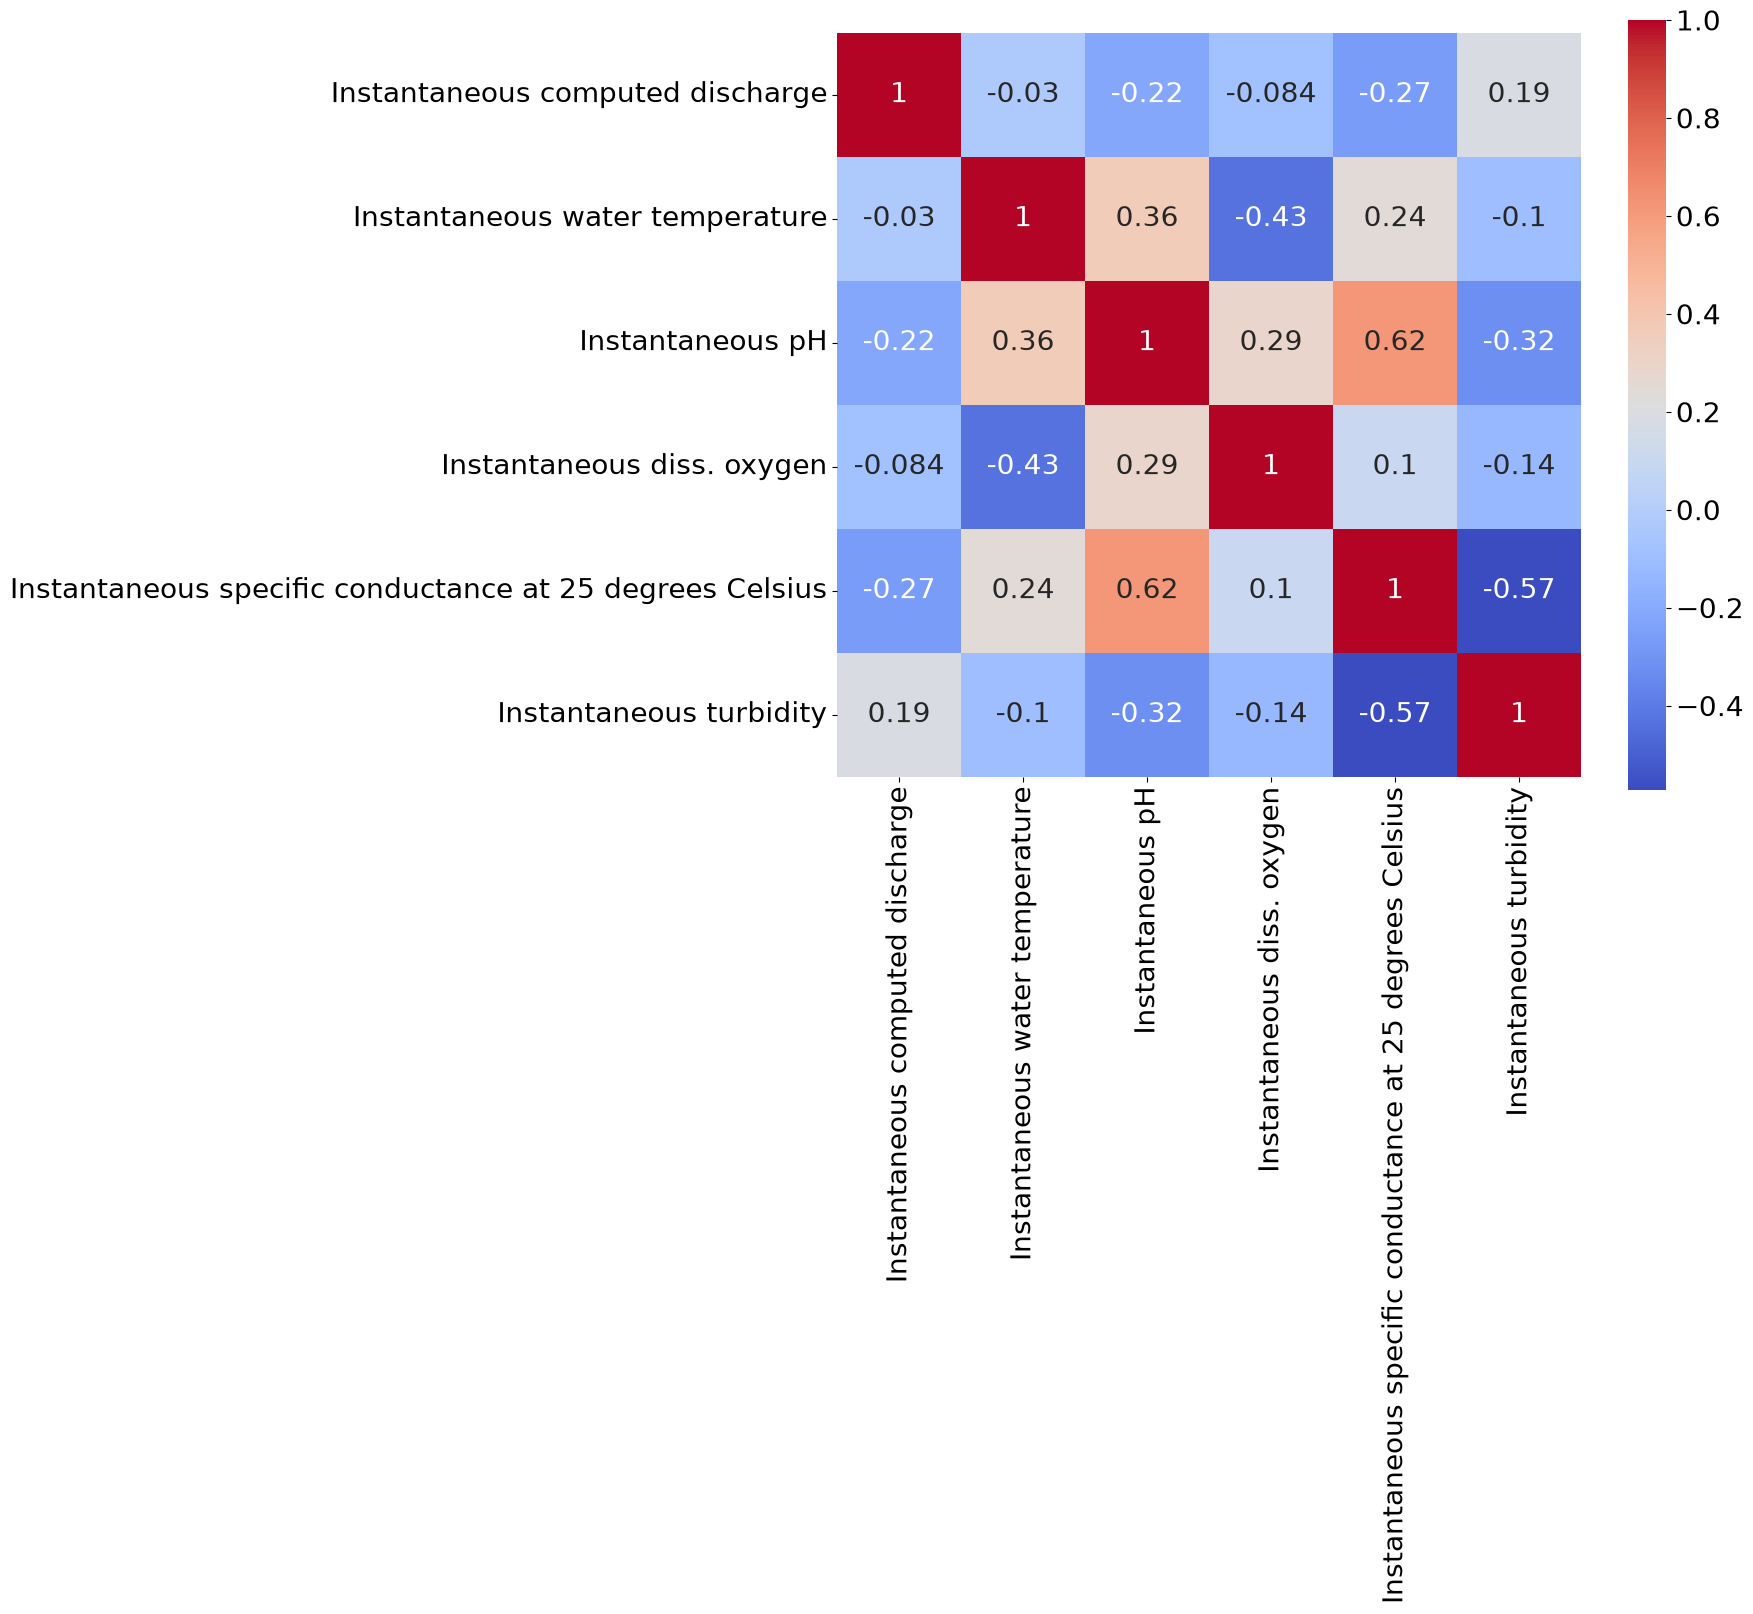

In [172]:
fig, ax = plt.subplots(figsize=(12,10))
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols[:]
#num_cols = num_cols.append(merged.columns[-1:])
corr = df[num_cols].corr(numeric_only=True)
plt.rcParams['font.size'] = 20
sns.heatmap(corr, annot=True, cmap="coolwarm",ax=ax)
ax.set_aspect(1)

In [124]:
df.index.name = "DateTime"

In [ ]:
# df.to_csv("USGS_data.csv")

In [126]:
df

,Discharge (cfs),Water Temperature (C),pH (std units),Dissolved Oxygen (mg/L),Specific Conductance (uS/cm),Turbidity (NTU),Precipitation 1hr (in)
DateTime,,,,,,,
2020-01-01 00:00:00,104.0,14.0,7.4,10.4,409.0,29.5,0.0
2020-01-01 01:00:00,102.0,13.6,7.4,10.2,421.0,30.3,0.0
2020-01-01 02:00:00,101.0,13.3,7.4,10.1,423.0,39.7,0.0
2020-01-01 03:00:00,101.0,12.9,7.4,10.0,424.0,37.0,0.0
2020-01-01 04:00:00,98.9,12.7,7.3,9.9,427.0,37.8,0.0
...,...,...,...,...,...,...,...
2024-12-31 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2024-12-31 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2024-12-31 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.0
